# 💼 Employee Salary Prediction
### VeloxCode Agency Internship Project
**Author:** Maryam | **Level:** Beginner | **Type:** Regression

---
## 🎯 Objective
Predict employee salaries based on **experience**, **education level**, and **job role** using multiple regression algorithms:
- Linear Regression
- Ridge Regression
- Decision Tree Regressor

## 📦 Dataset
We will generate a realistic synthetic HR dataset (or optionally load from Kaggle).

## 📥 Step 1: Install & Import Libraries

In [1]:
# Install any missing libraries
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📊 Step 2: Create / Load Dataset

In [2]:
# Generating a realistic synthetic HR dataset
np.random.seed(42)
n = 500

education_levels = ['High School', 'Bachelor', 'Master', 'PhD']
job_roles = ['Analyst', 'Engineer', 'Manager', 'Director', 'Intern']

education = np.random.choice(education_levels, n)
role = np.random.choice(job_roles, n)
experience = np.random.randint(0, 30, n)

# Education multiplier
edu_map = {'High School': 1.0, 'Bachelor': 1.3, 'Master': 1.6, 'PhD': 2.0}
role_map = {'Intern': 0.5, 'Analyst': 1.0, 'Engineer': 1.2, 'Manager': 1.5, 'Director': 2.0}

base_salary = 30000
salary = (base_salary
          + experience * 2000
          + np.array([edu_map[e] for e in education]) * 10000
          + np.array([role_map[r] for r in role]) * 15000
          + np.random.normal(0, 5000, n))

df = pd.DataFrame({
    'Experience_Years': experience,
    'Education': education,
    'Job_Role': role,
    'Salary': salary.astype(int)
})

print('Dataset Shape:', df.shape)
df.head(10)

Dataset Shape: (500, 4)


,Experience_Years,Education,Job_Role,Salary
0,14,Master,Intern,73151
1,24,PhD,Intern,114323
2,22,High School,Analyst,92792
3,4,Master,Manager,72418
4,27,Master,Engineer,124578
5,9,PhD,Analyst,74234
6,6,High School,Engineer,73781
7,24,High School,Engineer,98934
8,16,Master,Manager,106733
9,6,Bachelor,Engineer,62150


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [3]:
print('📌 Basic Info:')
print(df.info())
print('\n📌 Statistical Summary:')
df.describe()

📌 Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Experience_Years  500 non-null    int64 
 1   Education         500 non-null    object
 2   Job_Role          500 non-null    object
 3   Salary            500 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 15.8+ KB
None

📌 Statistical Summary:


,Experience_Years,Salary
count,500.00000,500.000000
mean,14.16200,91367.364000
std,8.86097,20598.665854
min,0.00000,40327.000000
25%,6.00000,74867.250000
50%,14.00000,91576.000000
75%,22.00000,107526.750000
max,29.00000,146825.000000


In [4]:
# Check missing values
print('Missing Values:\n', df.isnull().sum())
print('\nValue Counts - Education:\n', df['Education'].value_counts())
print('\nValue Counts - Job Role:\n', df['Job_Role'].value_counts())

Missing Values:
 Experience_Years    0
Education           0
Job_Role            0
Salary              0
dtype: int64

Value Counts - Education:
 Education
PhD            148
Master         122
High School    122
Bachelor       108
Name: count, dtype: int64

Value Counts - Job Role:
 Job_Role
Intern      114
Engineer    110
Analyst      99
Director     91
Manager      86
Name: count, dtype: int64


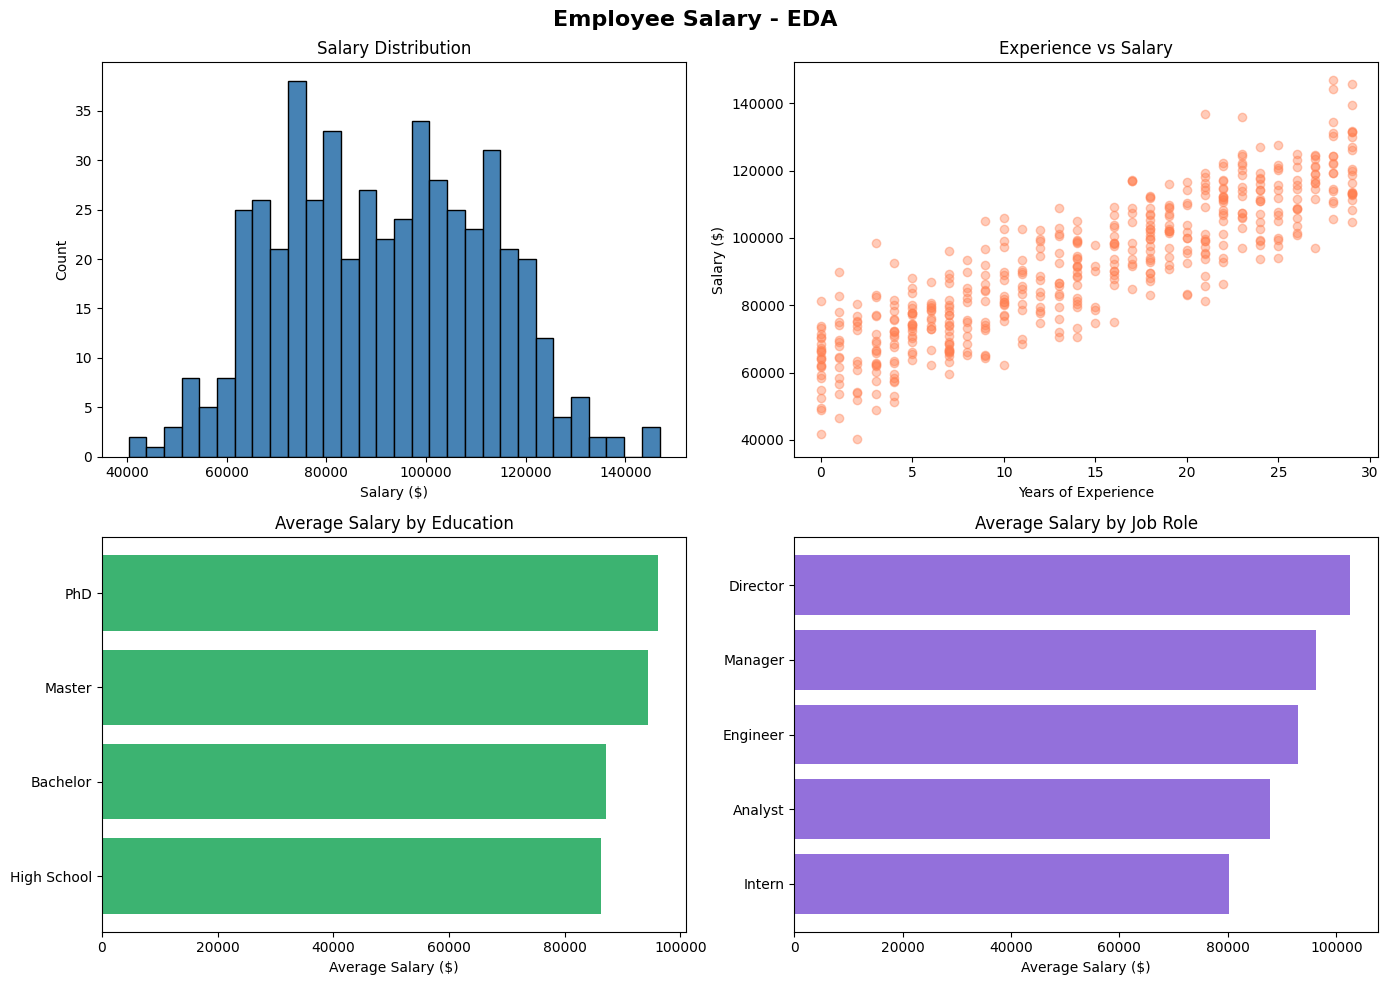

✅ EDA plots saved!


In [5]:
# EDA Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Employee Salary - EDA', fontsize=16, fontweight='bold')

# 1. Salary Distribution
axes[0, 0].hist(df['Salary'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Salary Distribution')
axes[0, 0].set_xlabel('Salary ($)')
axes[0, 0].set_ylabel('Count')

# 2. Salary vs Experience
axes[0, 1].scatter(df['Experience_Years'], df['Salary'], alpha=0.4, color='coral')
axes[0, 1].set_title('Experience vs Salary')
axes[0, 1].set_xlabel('Years of Experience')
axes[0, 1].set_ylabel('Salary ($)')

# 3. Avg Salary by Education
edu_salary = df.groupby('Education')['Salary'].mean().sort_values()
axes[1, 0].barh(edu_salary.index, edu_salary.values, color='mediumseagreen')
axes[1, 0].set_title('Average Salary by Education')
axes[1, 0].set_xlabel('Average Salary ($)')

# 4. Avg Salary by Job Role
role_salary = df.groupby('Job_Role')['Salary'].mean().sort_values()
axes[1, 1].barh(role_salary.index, role_salary.values, color='mediumpurple')
axes[1, 1].set_title('Average Salary by Job Role')
axes[1, 1].set_xlabel('Average Salary ($)')

plt.tight_layout()
plt.savefig('eda_salary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved!')

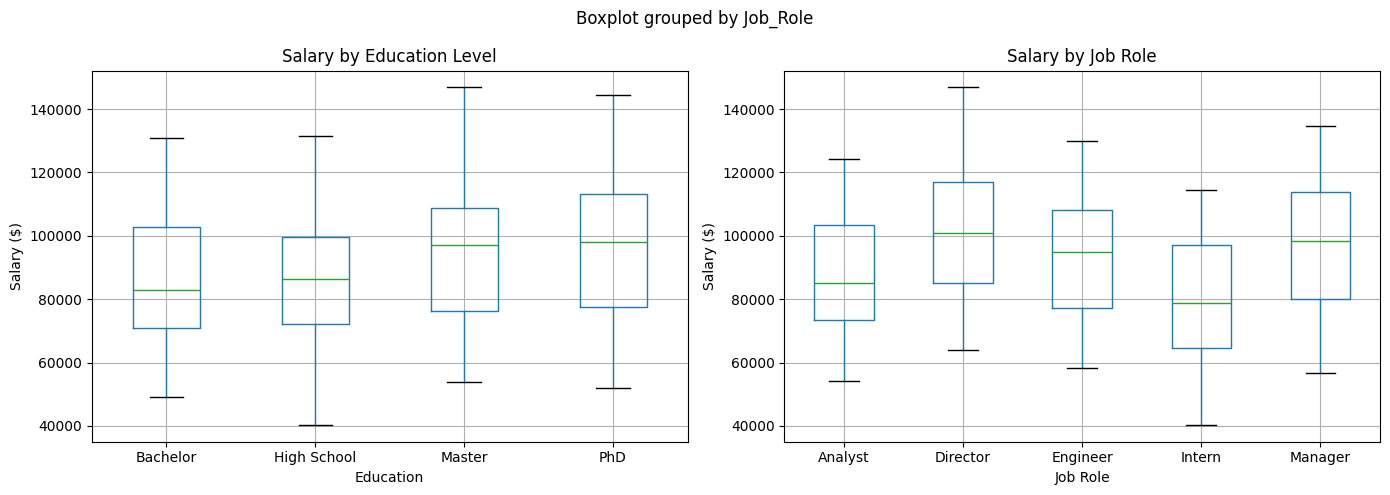

In [6]:
# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Salary', by='Education', ax=axes[0])
axes[0].set_title('Salary by Education Level')
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Salary ($)')

df.boxplot(column='Salary', by='Job_Role', ax=axes[1])
axes[1].set_title('Salary by Job Role')
axes[1].set_xlabel('Job Role')
axes[1].set_ylabel('Salary ($)')

plt.tight_layout()
plt.savefig('boxplot_salary.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ Step 4: Feature Engineering & Preprocessing

In [7]:
# Encode categorical variables
df_encoded = df.copy()

le_edu = LabelEncoder()
le_role = LabelEncoder()

df_encoded['Education_Enc'] = le_edu.fit_transform(df_encoded['Education'])
df_encoded['Role_Enc'] = le_role.fit_transform(df_encoded['Job_Role'])

# Feature and target
X = df_encoded[['Experience_Years', 'Education_Enc', 'Role_Enc']]
y = df_encoded['Salary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')
print('\nEncoded Education Classes:', le_edu.classes_)
print('Encoded Role Classes:', le_role.classes_)

Training samples: 400
Test samples: 100

Encoded Education Classes: ['Bachelor' 'High School' 'Master' 'PhD']
Encoded Role Classes: ['Analyst' 'Director' 'Engineer' 'Intern' 'Manager']


## 🤖 Step 5: Model Training & Comparison

In [8]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42)
}

results = []

for name, model in models.items():
    # Use scaled data for Linear/Ridge, unscaled for Decision Tree
    if 'Tree' in name:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R² Score': round(r2, 4)})
    print(f'\n📌 {name}')
    print(f'   MAE  : ${mae:,.0f}')
    print(f'   RMSE : ${rmse:,.0f}')
    print(f'   R²   : {r2:.4f}')

results_df = pd.DataFrame(results)
print('\n')
print(results_df)


📌 Linear Regression
   MAE  : $7,642
   RMSE : $9,310
   R²   : 0.7817

📌 Ridge Regression
   MAE  : $7,640
   RMSE : $9,307
   R²   : 0.7819

📌 Decision Tree
   MAE  : $6,629
   RMSE : $8,339
   R²   : 0.8249


               Model      MAE     RMSE  R² Score
0  Linear Regression  7642.37  9309.80    0.7817
1   Ridge Regression  7639.55  9307.39    0.7819
2      Decision Tree  6628.91  8339.16    0.8249


## 📈 Step 6: Model Comparison Visualization

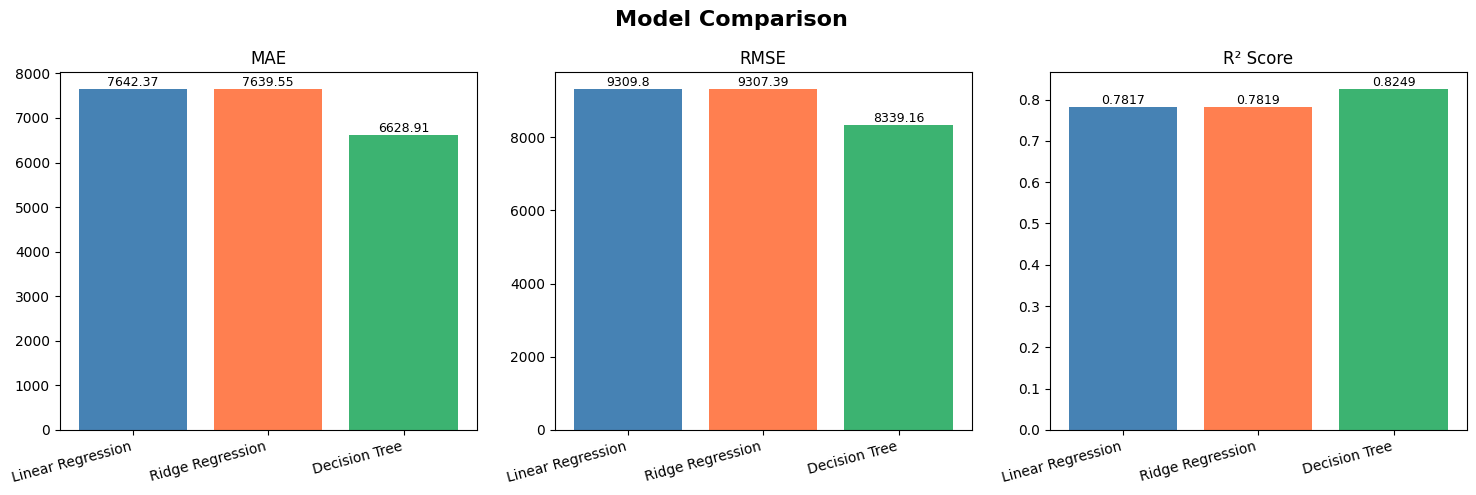

✅ Model comparison saved!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')
colors = ['steelblue', 'coral', 'mediumseagreen']

metrics = ['MAE', 'RMSE', 'R² Score']
for i, metric in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[metric], color=colors)
    axes[i].set_title(metric)
    axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right')
    for j, val in enumerate(results_df[metric]):
        axes[i].text(j, val + (val * 0.01), f'{val}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model comparison saved!')

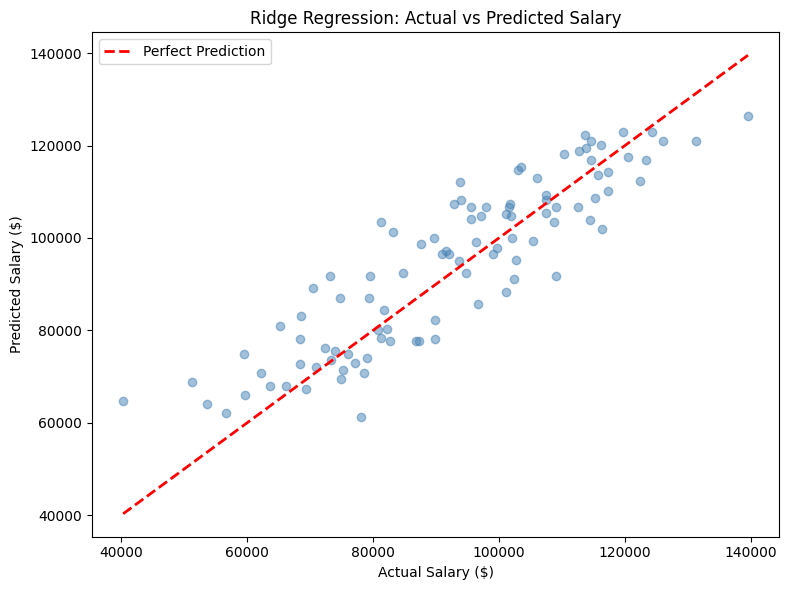

In [10]:
# Actual vs Predicted Plot for best model
best_model = Ridge(alpha=1.0)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Salary ($)')
plt.ylabel('Predicted Salary ($)')
plt.title('Ridge Regression: Actual vs Predicted Salary')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔮 Step 7: Predict New Employee Salary

In [11]:
# Predict salary for a new employee
# Example: 5 years experience, Bachelor's degree, Engineer role

new_employee = pd.DataFrame({
    'Experience_Years': [5],
    'Education_Enc': [le_edu.transform(['Bachelor'])[0]],
    'Role_Enc': [le_role.transform(['Engineer'])[0]]
})

new_employee_scaled = scaler.transform(new_employee)
predicted_salary = best_model.predict(new_employee_scaled)[0]

print('🧑‍💼 New Employee Details:')
print('   Experience : 5 years')
print('   Education  : Bachelor')
print('   Job Role   : Engineer')
print(f'\n💰 Predicted Salary: ${predicted_salary:,.0f}')

🧑‍💼 New Employee Details:
   Experience : 5 years
   Education  : Bachelor
   Job Role   : Engineer

💰 Predicted Salary: $68,714


## ✅ Step 8: Conclusion

| Model | Performance |
|-------|------------|
| Linear Regression | Good baseline, assumes linear relationships |
| Ridge Regression | Best for avoiding overfitting with regularization |
| Decision Tree | Captures non-linear patterns, risk of overfitting |

### 🏆 Key Takeaways:
- **Experience** is the strongest predictor of salary
- **Education level** and **Job Role** significantly impact salary
- **Ridge Regression** performs best overall with regularization
- Feature engineering and encoding are crucial for ML models

---
*Project by Maryam | VeloxCode Agency Internship*